# Analyse manuelle

Liste des **candidats** : indices présents à la fois dans `indices_pol_all_finetune_wrong.csv` et `indices_medical_all_finetune_wrong.csv`. En bas, tu choisis toi-même l'indice `idx` et une cellule affiche le prompt POL et le prompt MEDICAL associés (depuis `Prompt_cot/cot_test_pol.jsonl` et `cot_test_medical.jsonl`).

In [6]:
import pandas as pd
import json
import os

RESULTS_DIR = "."
PROMPT_COT_DIR = os.path.join(RESULTS_DIR, "Prompt_cot")

df_pol_wrong = pd.read_csv(os.path.join(RESULTS_DIR, "indices_pol_all_finetune_wrong.csv"))
df_medical_wrong = pd.read_csv(os.path.join(RESULTS_DIR, "indices_medical_all_finetune_wrong.csv"))

indices_pol = set(df_pol_wrong["index"].astype(int))
indices_medical = set(df_medical_wrong["index"].astype(int))
candidats = sorted(indices_pol & indices_medical)

print(f"Indices POL (tous finetune wrong): {len(indices_pol)}")
print(f"Indices MEDICAL (tous finetune wrong): {len(indices_medical)}")
print(f"Candidats (présents dans les deux): {len(candidats)}")
print(f"Liste des candidats: {candidats}")

Indices POL (tous finetune wrong): 196
Indices MEDICAL (tous finetune wrong): 174
Candidats (présents dans les deux): 123
Liste des candidats: [1, 16, 29, 30, 47, 78, 94, 135, 139, 144, 145, 155, 165, 182, 209, 231, 241, 246, 267, 280, 282, 302, 318, 336, 367, 388, 392, 393, 410, 412, 423, 428, 447, 455, 457, 475, 493, 497, 508, 514, 576, 582, 583, 587, 592, 600, 601, 602, 660, 731, 745, 748, 800, 801, 811, 820, 821, 830, 834, 835, 866, 872, 891, 896, 906, 909, 922, 951, 966, 976, 980, 992, 996, 1003, 1012, 1014, 1019, 1061, 1073, 1102, 1108, 1115, 1126, 1136, 1157, 1160, 1172, 1187, 1189, 1205, 1210, 1233, 1289, 1296, 1306, 1331, 1342, 1346, 1357, 1363, 1365, 1371, 1382, 1390, 1395, 1420, 1433, 1448, 1461, 1462, 1481, 1485, 1495, 1507, 1516, 1525, 1550, 1556, 1557, 1562, 1565, 1566, 1574]


In [7]:
def load_prompts_by_index(jsonl_path):
    """Charge le JSONL et retourne un dict index -> contenu du message user (prompt)."""
    prompts = {}
    with open(jsonl_path, "r", encoding="utf-8") as f:
        for i, line in enumerate(f):
            obj = json.loads(line)
            user_msg = next((m["content"] for m in obj["messages"] if m["role"] == "user"), "")
            prompts[i] = user_msg
    return prompts

path_pol = os.path.join(PROMPT_COT_DIR, "cot_test_pol.jsonl")
path_medical = os.path.join(PROMPT_COT_DIR, "cot_test_medical.jsonl")
prompts_pol = load_prompts_by_index(path_pol)
prompts_medical = load_prompts_by_index(path_medical)

df_eval = pd.read_csv(os.path.join(PROMPT_COT_DIR, "eval_cot_combined_finetune.csv"))
df_eval_baseline = pd.read_csv(os.path.join(PROMPT_COT_DIR, "eval_cot_combined_baseline.csv"))
print(f"Prompts POL chargés: {len(prompts_pol)}, MEDICAL: {len(prompts_medical)}")
print(f"Eval CoT finetune: {len(df_eval)} lignes, baseline: {len(df_eval_baseline)} lignes")

Prompts POL chargés: 1578, MEDICAL: 1578
Eval CoT finetune: 3156 lignes, baseline: 3156 lignes


## Affichage manuel : choisis l'indice `idx` ci-dessous puis exécute la cellule pour afficher les deux prompts, le reasoning et la prediction (depuis l'éval CoT finetune).

In [8]:
# Choisis l'indice (ex. un des candidats) puis exécute la cellule
idx = 29

row_pol = df_eval[(df_eval["index"] == idx) & (df_eval["statement_type"] == "pol")].iloc[0] if len(df_eval[(df_eval["index"] == idx) & (df_eval["statement_type"] == "pol")]) else None
row_medical = df_eval[(df_eval["index"] == idx) & (df_eval["statement_type"] == "medical")].iloc[0] if len(df_eval[(df_eval["index"] == idx) & (df_eval["statement_type"] == "medical")]) else None

print("=" * 80)
print(f"Index = {idx}")
print("=" * 80)
print("\n--- Prompt POL ---\n")
print(prompts_pol.get(idx, "(index absent dans cot_test_pol.jsonl)"))
if row_pol is not None:
    print("\n  [Eval] gold:", row_pol["gold"], " | prediction:", row_pol["prediction"], " | is_correct:", row_pol["is_correct"])
    print("  [Eval] reasoning:\n", row_pol["reasoning"] if pd.notna(row_pol.get("reasoning")) else "(n/a)")
print("\n--- Prompt MEDICAL ---\n")
print(prompts_medical.get(idx, "(index absent dans cot_test_medical.jsonl)"))
if row_medical is not None:
    print("\n  [Eval] gold:", row_medical["gold"], " | prediction:", row_medical["prediction"], " | is_correct:", row_medical["is_correct"])
    print("  [Eval] reasoning:\n", row_medical["reasoning"] if pd.notna(row_medical.get("reasoning")) else "(n/a)")

Index = 29

--- Prompt POL ---

Does the patient with the statement "I had to rush to the ER because of a non-stop nosebleed that had been on for 1 hour. As a 23-year-old, I always had heavy periods, and sometimes, my gums would bleed after going to the dentist or brushing my teeth. I thought that it was not very alarming since my mom also had heavy periods. I did some lab tests that showed that I had increased bleeding time and long clotting time. Otherwise, I'm pretty healthy, and I don't smoke or take any kind of drugs. I drink only at parties from time to time. I have been with my boyfriend for the last 2 years. I did a coagulation study and I got the following results: CB = 0.30 IU/mL and FVIII:C = 0.37 IU/mL." satisfy the following clinical trial admission criteria ?
"Inclusion Criteria:

          -  Women with menorrhagia

          -  18-49 years of age

          -  Regularly occuring menstrual periods

        Exclusion Criteria:

          -  History or presence of clinical

## Même idx — affichage **baseline** (reasoning et prediction)

In [9]:
row_pol_b = df_eval_baseline[(df_eval_baseline["index"] == idx) & (df_eval_baseline["statement_type"] == "pol")].iloc[0] if len(df_eval_baseline[(df_eval_baseline["index"] == idx) & (df_eval_baseline["statement_type"] == "pol")]) else None
row_medical_b = df_eval_baseline[(df_eval_baseline["index"] == idx) & (df_eval_baseline["statement_type"] == "medical")].iloc[0] if len(df_eval_baseline[(df_eval_baseline["index"] == idx) & (df_eval_baseline["statement_type"] == "medical")]) else None

print("=" * 80)
print(f"Index = {idx} — BASELINE")
print("=" * 80)
print("\n--- Prompt POL ---\n")
print(prompts_pol.get(idx, "(index absent dans cot_test_pol.jsonl)"))
if row_pol_b is not None:
    print("\n  [Eval baseline] gold:", row_pol_b["gold"], " | prediction:", row_pol_b["prediction"], " | is_correct:", row_pol_b["is_correct"])
    print("  [Eval baseline] reasoning:\n", row_pol_b["reasoning"] if pd.notna(row_pol_b.get("reasoning")) else "(n/a)")
print("\n--- Prompt MEDICAL ---\n")
print(prompts_medical.get(idx, "(index absent dans cot_test_medical.jsonl)"))
if row_medical_b is not None:
    print("\n  [Eval baseline] gold:", row_medical_b["gold"], " | prediction:", row_medical_b["prediction"], " | is_correct:", row_medical_b["is_correct"])
    print("  [Eval baseline] reasoning:\n", row_medical_b["reasoning"] if pd.notna(row_medical_b.get("reasoning")) else "(n/a)")

Index = 29 — BASELINE

--- Prompt POL ---

Does the patient with the statement "I had to rush to the ER because of a non-stop nosebleed that had been on for 1 hour. As a 23-year-old, I always had heavy periods, and sometimes, my gums would bleed after going to the dentist or brushing my teeth. I thought that it was not very alarming since my mom also had heavy periods. I did some lab tests that showed that I had increased bleeding time and long clotting time. Otherwise, I'm pretty healthy, and I don't smoke or take any kind of drugs. I drink only at parties from time to time. I have been with my boyfriend for the last 2 years. I did a coagulation study and I got the following results: CB = 0.30 IU/mL and FVIII:C = 0.37 IU/mL." satisfy the following clinical trial admission criteria ?
"Inclusion Criteria:

          -  Women with menorrhagia

          -  18-49 years of age

          -  Regularly occuring menstrual periods

        Exclusion Criteria:

          -  History or presence 

## Analyse linguistique : comparaison candidats vs autres indices

On calcule les mêmes métriques linguistiques que dans NLI4CT pour comparer les **candidats** (indices problématiques) à la **moyenne des autres indices** du test. Pour chaque métrique qui concerne le statement, on fait séparément POL et MEDICAL.


In [10]:
import re
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['font.size'] = 10

# Créer le dossier pour les graphiques
# Le notebook est dans NLI4PR/results/, donc .parent = NLI4PR/
NLI4PR_ROOT = Path(".").resolve().parent
GRAPHS_DIR = NLI4PR_ROOT / "graphes"
GRAPHS_DIR.mkdir(parents=True, exist_ok=True)

# Charger le test.parquet
TEST_PARQUET = NLI4PR_ROOT / "data" / "test-00000-of-00001.parquet"
df_test = pd.read_parquet(TEST_PARQUET)

print(f"Test parquet chargé: {len(df_test)} lignes")
print(f"Colonnes: {list(df_test.columns)}")
print(f"Dossier graphiques: {GRAPHS_DIR}")
print(f"Chemin test.parquet: {TEST_PARQUET}")


Test parquet chargé: 1578 lignes
Colonnes: ['id', 'topic_id', 'statement_medical', 'statement_pol', 'premise', 'NCT_title', 'NCT_id', 'label']
Dossier graphiques: C:\Users\KEBDI Lounès\Documents\Projets\NLI_Finetuning\NLI4PR\graphes
Chemin test.parquet: C:\Users\KEBDI Lounès\Documents\Projets\NLI_Finetuning\NLI4PR\data\test-00000-of-00001.parquet


### Fonctions de calcul des métriques linguistiques


In [11]:
def tokenize(text):
    """Mots en minuscules, alphanumeriques."""
    if pd.isna(text) or not isinstance(text, str):
        return set()
    return set(re.findall(r"[a-zA-Z0-9À-ÿ]+", text.lower()))

def lexical_overlap(premise, hypothesis):
    """Jaccard + % mots de l'hypothèse présents dans la prémisse (coverage)."""
    p, h = tokenize(premise), tokenize(hypothesis)
    if not p and not h:
        return 0.0, 0.0
    inter = len(p & h)
    union = len(p | h)
    jaccard = inter / union if union else 0.0
    coverage = inter / len(h) if h else 0.0  # % des mots de l'hypothèse dans la prémisse
    return jaccard, coverage

def numeric_density(text):
    """Nombre de chiffres, de pourcentages (\d+%), et d'unités (mg, g, ml, ans, years, etc.)."""
    if pd.isna(text) or not isinstance(text, str):
        return 0, 0, 0
    digits = len(re.findall(r"\d", text))
    pct = len(re.findall(r"\d+%", text))
    units = len(re.findall(r"\d+\s*(?:mg|g|ml|mL|kg|years?|yrs?|months?|days?|weeks?|cycles?|doses?|mg/m²|m²)", text, re.I))
    return digits, pct, units

def negation_presence(text):
    """Compte d'occurrences de négations (non, aucun, sans, ne pas, ni, jamais, etc.)."""
    if pd.isna(text) or not isinstance(text, str):
        return 0
    t = text.lower()
    neg = re.findall(r"\b(?:non|aucun|aucune|sans|ni\b|jamais|pas\b|n'est|n'ont|ne pas|ne pas|not\b|no\b|none|never|cannot|can't)", t)
    return len(neg)

def trial_keywords(text):
    """Présence de mots clés 'primary' / 'secondary' (trial)."""
    if pd.isna(text) or not isinstance(text, str):
        return 0, 0
    t = text.lower()
    primary = len(re.findall(r"primary\s+(?:trial)?", t))
    secondary = len(re.findall(r"secondary\s+(?:trial)?", t))
    return primary, secondary

def word_count(text):
    """Compte le nombre de mots dans un texte."""
    if pd.isna(text) or not isinstance(text, str):
        return 0
    return len(re.findall(r"[a-zA-Z0-9À-ÿ]+", text))


### Calcul des métriques pour tous les indices (POL et MEDICAL)


In [12]:
def compute_features_for_df(df, premise_col, statement_col):
    """
    Calcule toutes les métriques linguistiques pour un DataFrame.
    premise_col: nom de la colonne contenant la prémisse
    statement_col: nom de la colonne contenant le statement (hypothesis)
    Utilise l'index du DataFrame comme identifiant (ou la colonne 'id' si elle existe).
    """
    features_list = []
    for idx, row in df.iterrows():
        # Utiliser l'index du DataFrame comme identifiant (correspond aux indices dans les CSV)
        index_val = idx
        
        premise = str(row[premise_col]) if pd.notna(row[premise_col]) else ""
        statement = str(row[statement_col]) if pd.notna(row[statement_col]) else ""
        
        # Chevauchement lexical
        jaccard, coverage = lexical_overlap(premise, statement)
        
        # Densité numérique
        digits_p, pct_p, units_p = numeric_density(premise)
        digits_s, pct_s, units_s = numeric_density(statement)
        
        # Négations
        neg_p = negation_presence(premise)
        neg_s = negation_presence(statement)
        
        # Mots-clés trial
        prim_p, sec_p = trial_keywords(premise)
        prim_s, sec_s = trial_keywords(statement)
        
        # Longueur
        words_p = word_count(premise)
        words_s = word_count(statement)
        
        features_list.append({
            'index': index_val,
            'lexical_jaccard': jaccard,
            'lexical_coverage': coverage,
            'digits_premise': digits_p,
            'digits_statement': digits_s,
            'pct_premise': pct_p,
            'pct_statement': pct_s,
            'units_premise': units_p,
            'units_statement': units_s,
            'numeric_total': digits_p + digits_s + units_p + units_s + pct_p + pct_s,
            'neg_premise': neg_p,
            'neg_statement': neg_s,
            'neg_total': neg_p + neg_s,
            'words_premise': words_p,
            'words_statement': words_s,
            'trial_primary': prim_p + prim_s,
            'trial_secondary': sec_p + sec_s,
        })
    return pd.DataFrame(features_list)

# Calculer les métriques pour POL
print("Calcul des métriques pour POL...")
df_pol_features = compute_features_for_df(df_test, 'premise', 'statement_pol')
print(f"Métriques POL calculées: {len(df_pol_features)} lignes")

# Calculer les métriques pour MEDICAL
print("\nCalcul des métriques pour MEDICAL...")
df_medical_features = compute_features_for_df(df_test, 'premise', 'statement_medical')
print(f"Métriques MEDICAL calculées: {len(df_medical_features)} lignes")


Calcul des métriques pour POL...
Métriques POL calculées: 1578 lignes

Calcul des métriques pour MEDICAL...
Métriques MEDICAL calculées: 1578 lignes


### Comparaison candidats vs autres indices



=== POL ===
Candidats: 123 | Autres: 1455

Chevauchement lexical (Jaccard):
  Candidats: 0.0792
  Autres:    0.0756
  Différence: +0.0037 (+4.83%)

Coverage lexical (%):
  Candidats: 0.1834
  Autres:    0.1957
  Différence: -0.0122 (-6.24%)

Densité numérique totale:
  Candidats: 30.9268
  Autres:    37.2935
  Différence: -6.3666 (-17.07%)

Négations totales:
  Candidats: 3.9919
  Autres:    4.2495
  Différence: -0.2576 (-6.06%)

Longueur prémisse (mots):
  Candidats: 198.3821
  Autres:    251.9450
  Différence: -53.5629 (-21.26%)

Longueur statement (mots):
  Candidats: 120.8862
  Autres:    117.4192
  Différence: +3.4669 (+2.95%)

Chiffres dans statement:
  Candidats: 6.4472
  Autres:    6.4997
  Différence: -0.0525 (-0.81%)

Pourcentages dans statement:
  Candidats: 0.1382
  Autres:    0.0969
  Différence: +0.0413 (+42.62%)

Unités dans statement:
  Candidats: 0.5366
  Autres:    0.7436
  Différence: -0.2071 (-27.84%)

Négations dans statement:
  Candidats: 1.0163
  Autres:    0.91

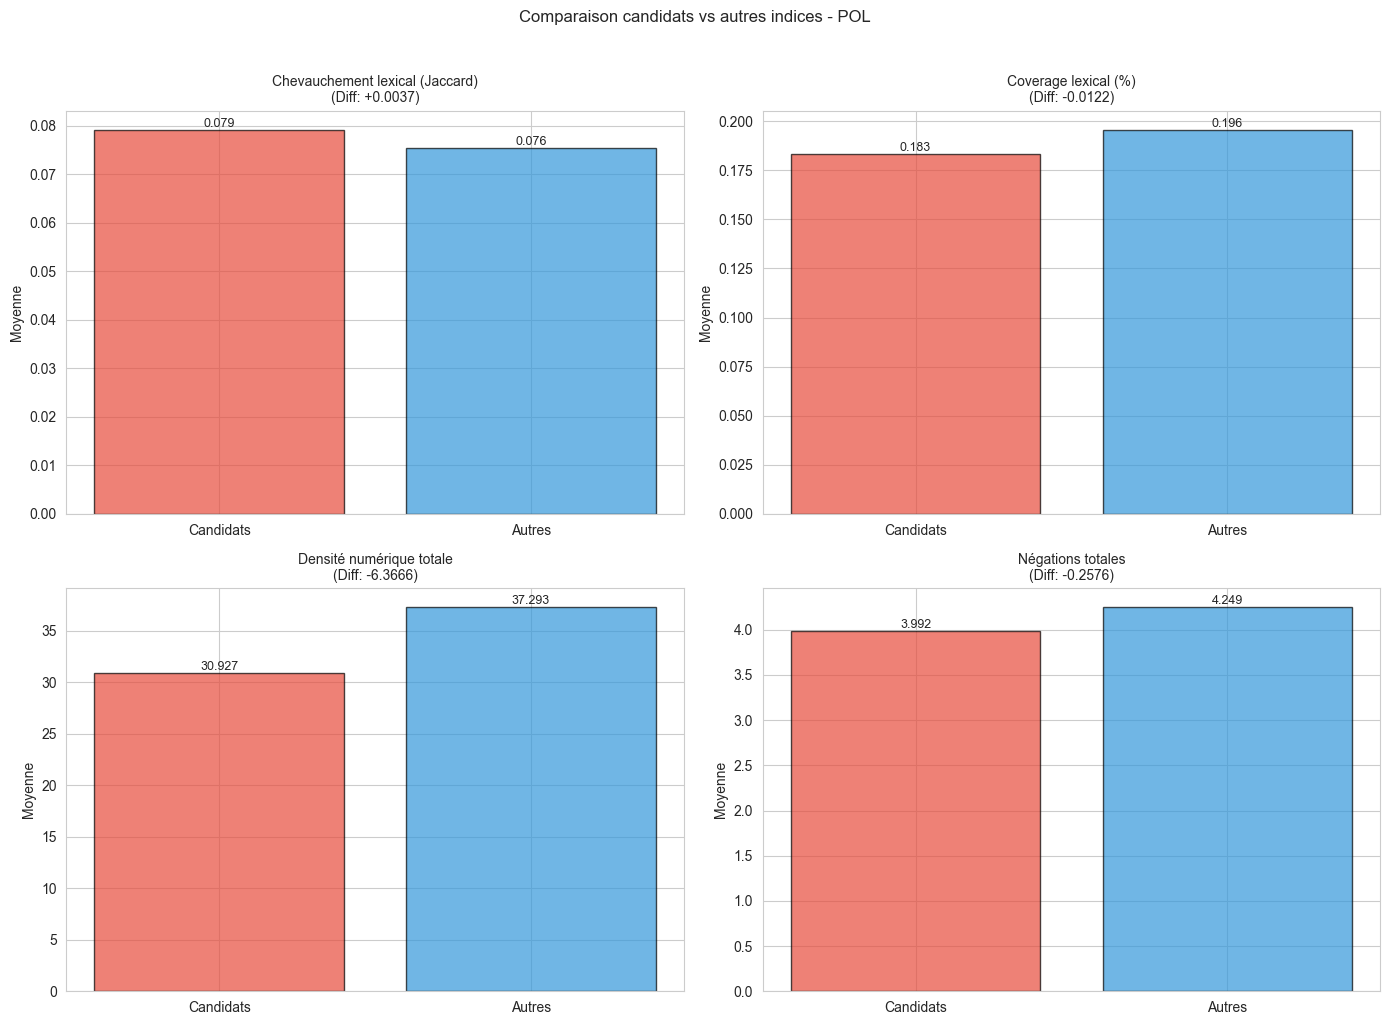

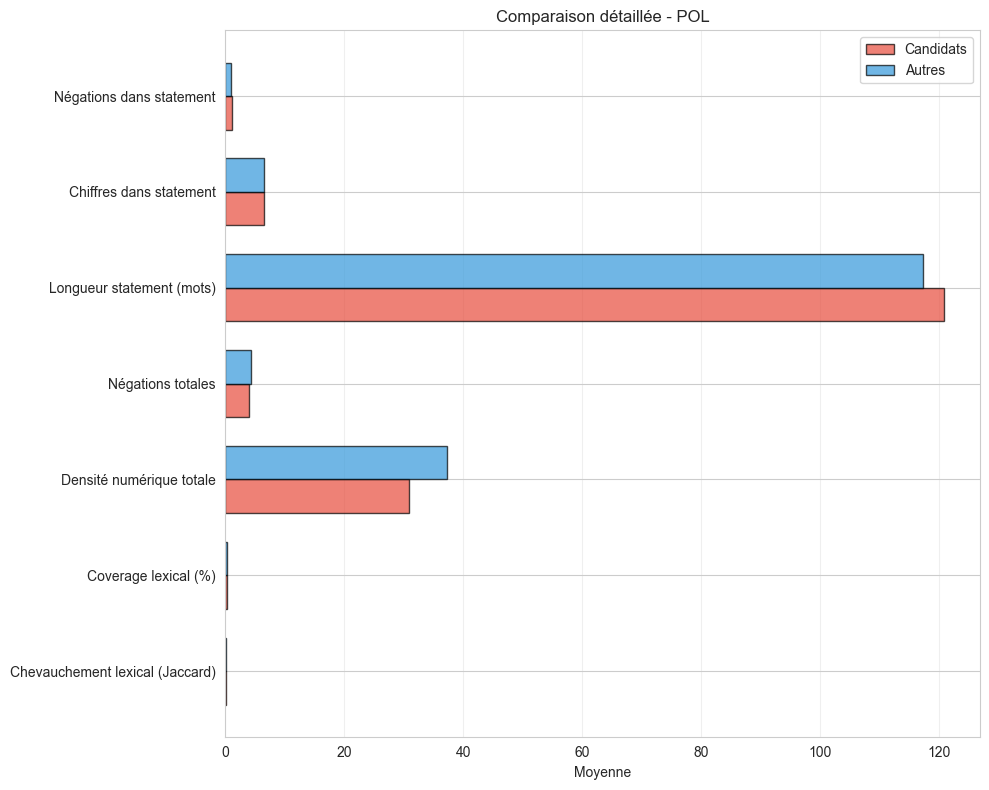

C:\Users\KEBDI Lounès\AppData\Local\Temp\ipykernel_2180\436281846.py:134: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_to_plot, labels=['Candidats', 'Autres'],
C:\Users\KEBDI Lounès\AppData\Local\Temp\ipykernel_2180\436281846.py:134: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_to_plot, labels=['Candidats', 'Autres'],
C:\Users\KEBDI Lounès\AppData\Local\Temp\ipykernel_2180\436281846.py:134: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_to_plot, labels=['Candidats', 'Autres'],
C:\Users\KEBDI Lounès\AppData\Local\Temp\ipykernel_2180\436281846.py:134: Matpl

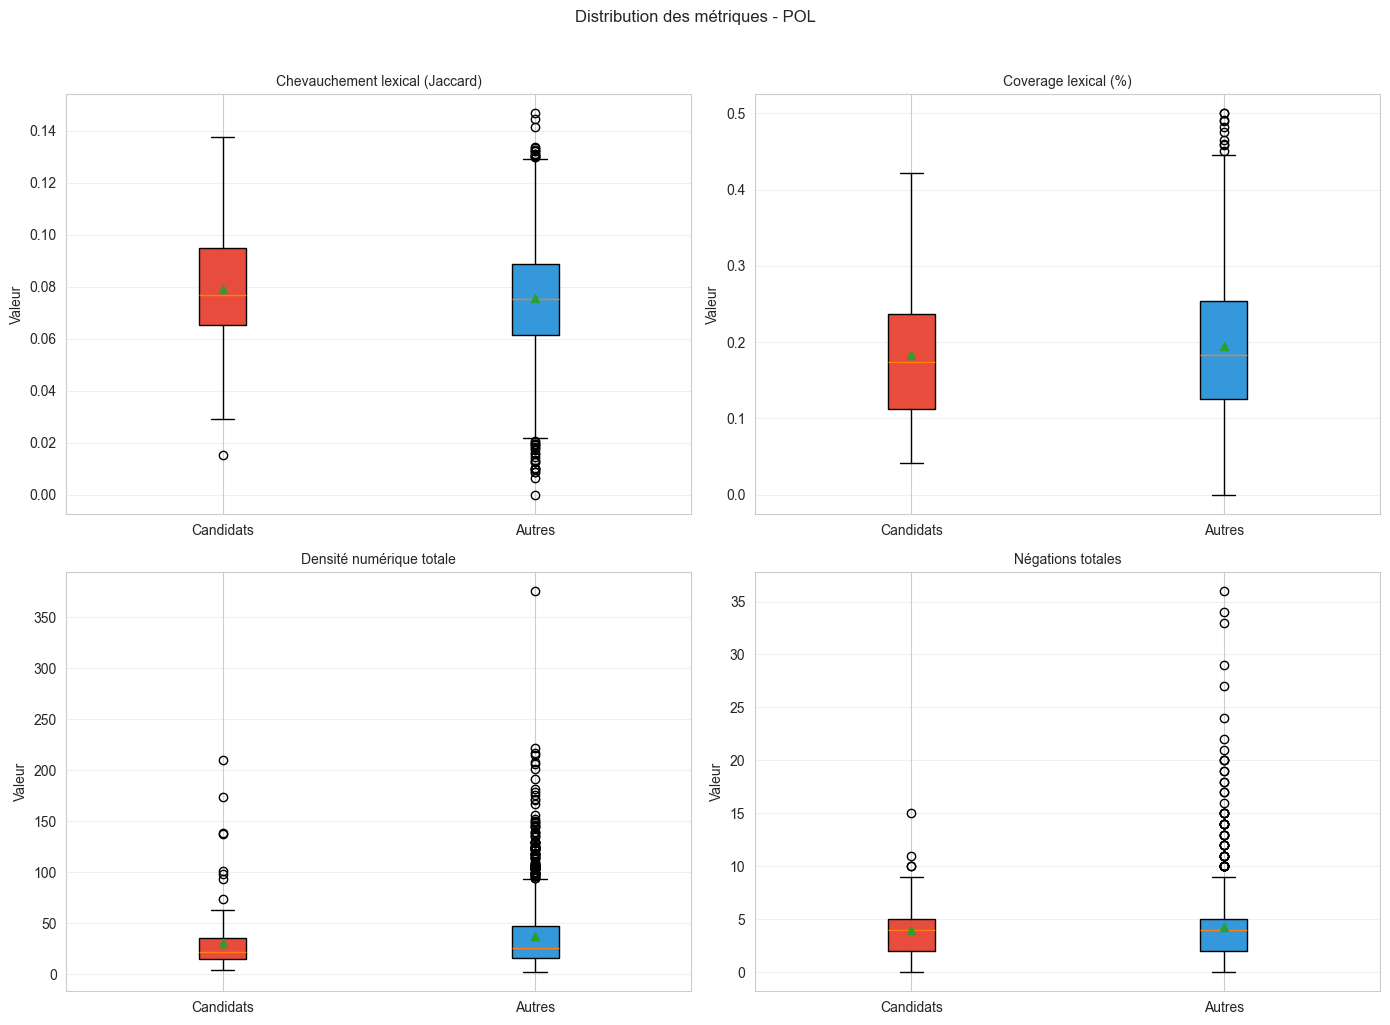


=== MEDICAL ===
Candidats: 123 | Autres: 1455

Chevauchement lexical (Jaccard):
  Candidats: 0.0945
  Autres:    0.0908
  Différence: +0.0037 (+4.04%)

Coverage lexical (%):
  Candidats: 0.2133
  Autres:    0.2328
  Différence: -0.0196 (-8.40%)

Densité numérique totale:
  Candidats: 32.8049
  Autres:    40.0818
  Différence: -7.2769 (-18.16%)

Négations totales:
  Candidats: 4.6911
  Autres:    4.7540
  Différence: -0.0629 (-1.32%)

Longueur prémisse (mots):
  Candidats: 198.3821
  Autres:    251.9450
  Différence: -53.5629 (-21.26%)

Longueur statement (mots):
  Candidats: 103.7317
  Autres:    101.5244
  Différence: +2.2073 (+2.17%)

Chiffres dans statement:
  Candidats: 8.1951
  Autres:    9.0392
  Différence: -0.8441 (-9.34%)

Pourcentages dans statement:
  Candidats: 0.1382
  Autres:    0.0969
  Différence: +0.0413 (+42.62%)

Unités dans statement:
  Candidats: 0.6667
  Autres:    0.9924
  Différence: -0.3258 (-32.83%)

Négations dans statement:
  Candidats: 1.7154
  Autres:    

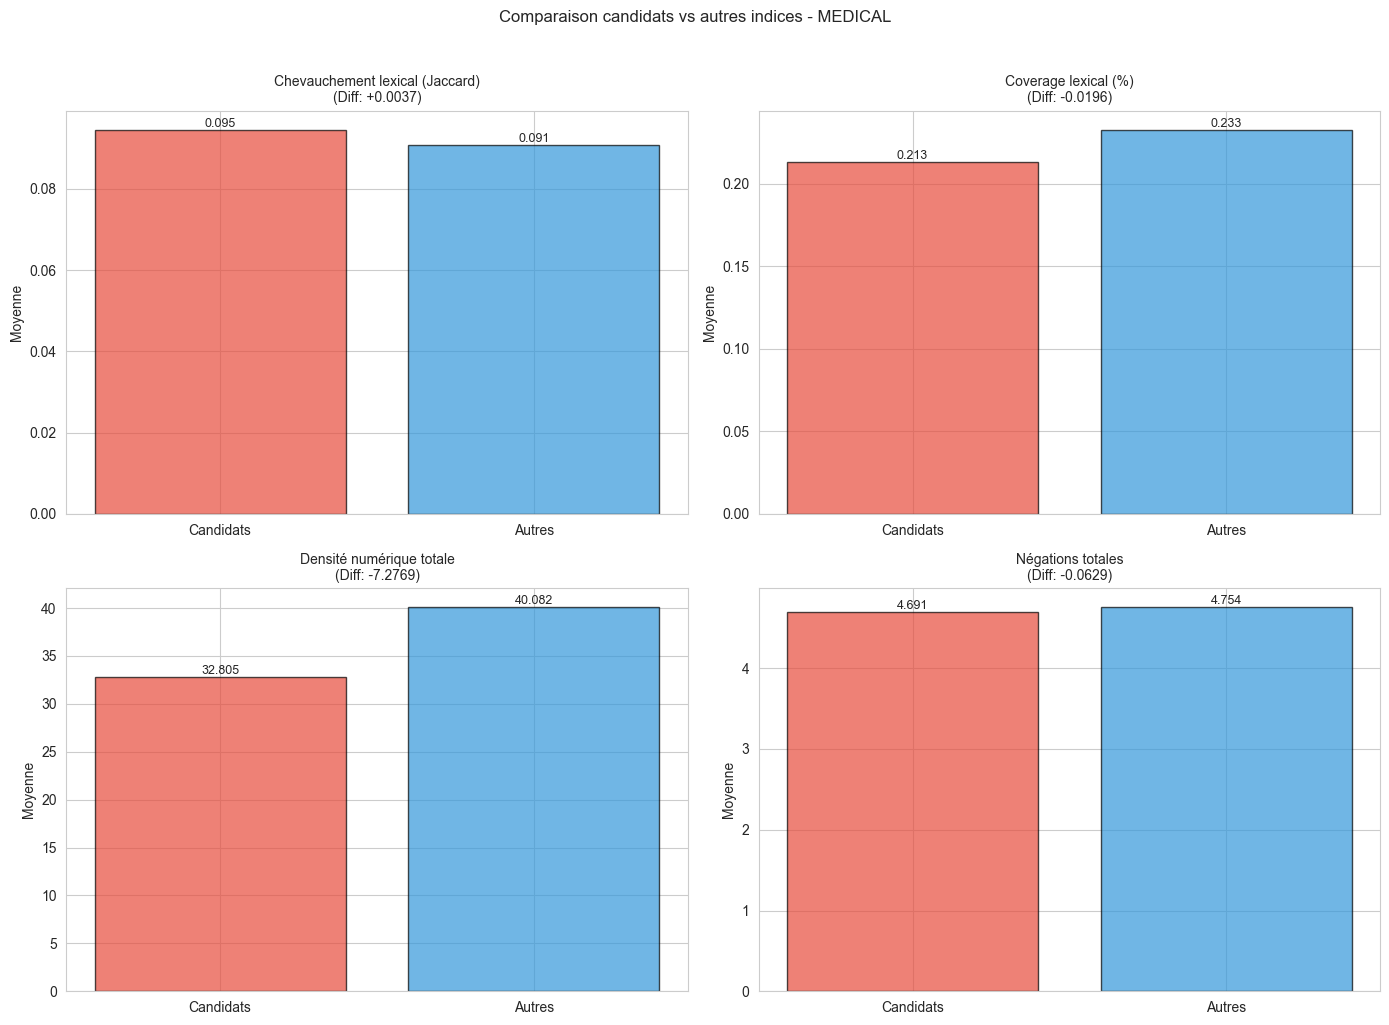

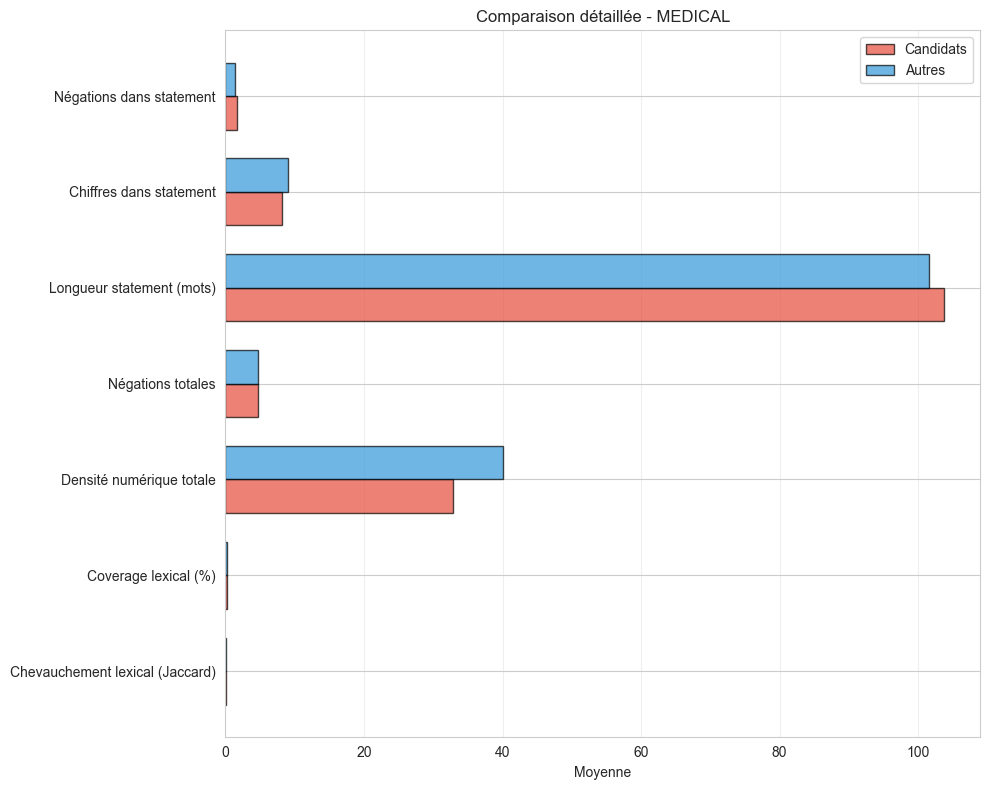

C:\Users\KEBDI Lounès\AppData\Local\Temp\ipykernel_2180\436281846.py:134: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_to_plot, labels=['Candidats', 'Autres'],
C:\Users\KEBDI Lounès\AppData\Local\Temp\ipykernel_2180\436281846.py:134: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_to_plot, labels=['Candidats', 'Autres'],
C:\Users\KEBDI Lounès\AppData\Local\Temp\ipykernel_2180\436281846.py:134: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_to_plot, labels=['Candidats', 'Autres'],
C:\Users\KEBDI Lounès\AppData\Local\Temp\ipykernel_2180\436281846.py:134: Matpl

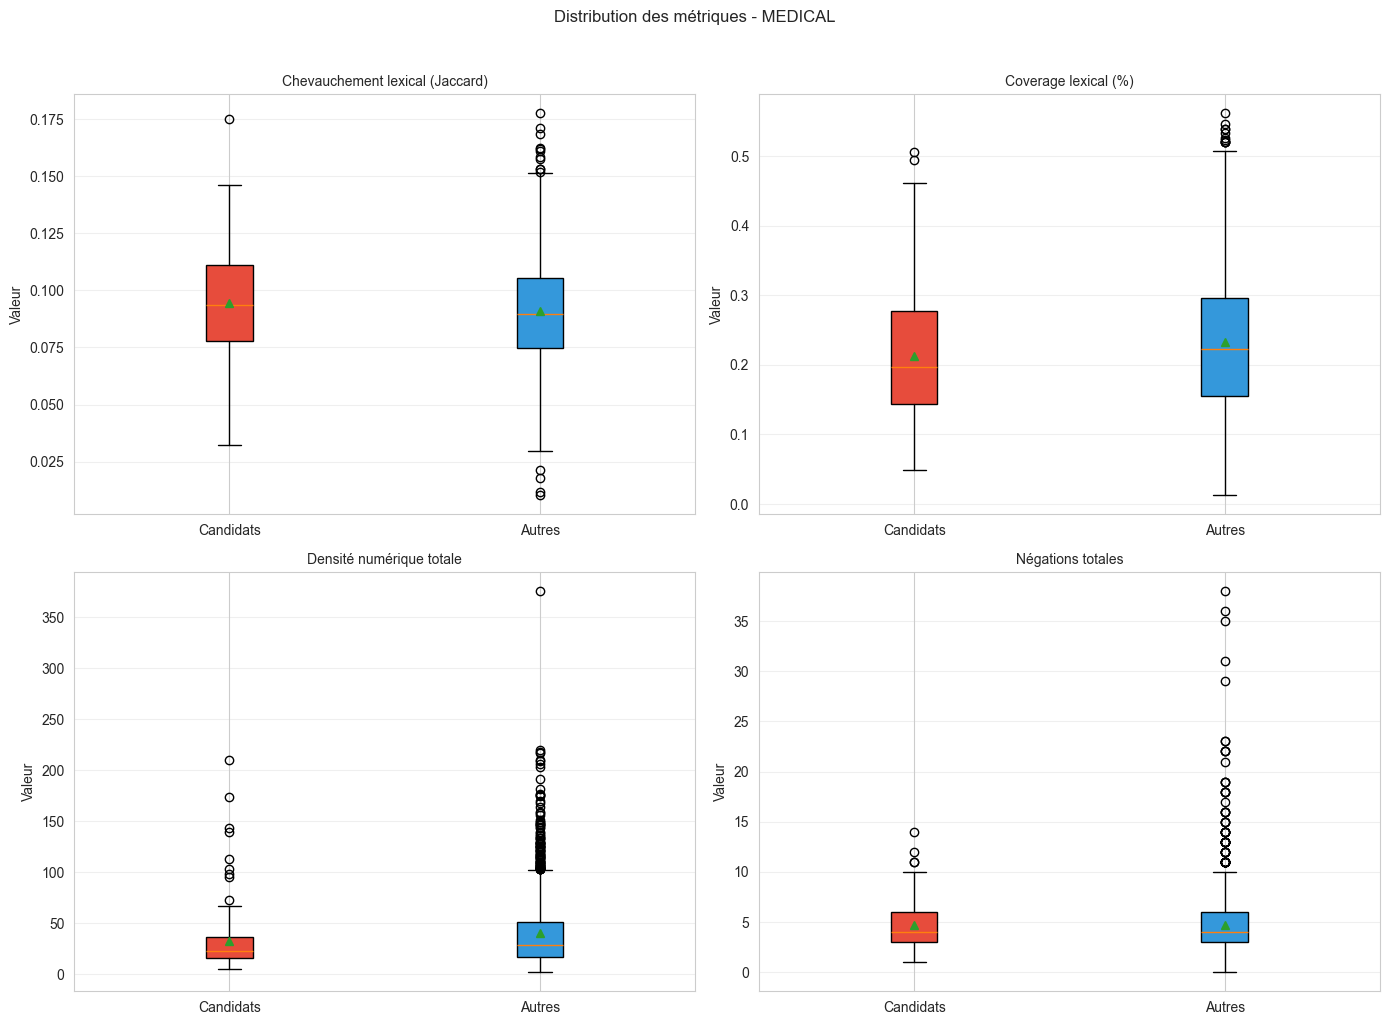

In [13]:
# Séparer les candidats des autres indices
set_candidats = set(candidats)

def compare_candidates_vs_others(df_features, task_name, set_candidats):
    """
    Compare les moyennes des candidats vs les autres indices pour toutes les métriques.
    Génère des visualisations adaptées.
    """
    # Filtrer les indices valides (qui existent dans df_features)
    valid_indices = set(df_features['index'].values)
    candidats_valid = [c for c in set_candidats if c in valid_indices]
    autres_valid = [i for i in valid_indices if i not in set_candidats]
    
    df_candidats = df_features[df_features['index'].isin(candidats_valid)]
    df_autres = df_features[df_features['index'].isin(autres_valid)]
    
    print(f"\n=== {task_name} ===")
    print(f"Candidats: {len(df_candidats)} | Autres: {len(df_autres)}")
    
    # Métriques à comparer (celles qui concernent le statement sont séparées POL/MEDICAL)
    metrics_to_compare = [
        ('lexical_jaccard', 'Chevauchement lexical (Jaccard)'),
        ('lexical_coverage', 'Coverage lexical (%)'),
        ('numeric_total', 'Densité numérique totale'),
        ('neg_total', 'Négations totales'),
        ('words_premise', 'Longueur prémisse (mots)'),
        ('words_statement', 'Longueur statement (mots)'),
        ('digits_statement', 'Chiffres dans statement'),
        ('pct_statement', 'Pourcentages dans statement'),
        ('units_statement', 'Unités dans statement'),
        ('neg_statement', 'Négations dans statement'),
        ('trial_primary', 'Mots-clés "primary trial"'),
        ('trial_secondary', 'Mots-clés "secondary trial"'),
    ]
    
    comparison_results = []
    
    for metric, metric_label in metrics_to_compare:
        if metric not in df_features.columns:
            continue
        
        mean_candidats = df_candidats[metric].mean()
        mean_autres = df_autres[metric].mean()
        diff = mean_candidats - mean_autres
        diff_pct = (diff / mean_autres * 100) if mean_autres != 0 else 0
        
        comparison_results.append({
            'metric': metric,
            'metric_label': metric_label,
            'mean_candidats': mean_candidats,
            'mean_autres': mean_autres,
            'diff': diff,
            'diff_pct': diff_pct,
        })
        
        print(f"\n{metric_label}:")
        print(f"  Candidats: {mean_candidats:.4f}")
        print(f"  Autres:    {mean_autres:.4f}")
        print(f"  Différence: {diff:+.4f} ({diff_pct:+.2f}%)")
    
    df_comparison = pd.DataFrame(comparison_results)
    
    # Visualisations
    # 1. Graphique en barres comparant les moyennes
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    axes = axes.flatten()
    
    # Sélectionner les 4 métriques principales pour le graphique
    main_metrics = ['lexical_jaccard', 'lexical_coverage', 'numeric_total', 'neg_total']
    for i, metric in enumerate(main_metrics):
        if metric not in df_comparison['metric'].values:
            continue
        row = df_comparison[df_comparison['metric'] == metric].iloc[0]
        ax = axes[i]
        categories = ['Candidats', 'Autres']
        values = [row['mean_candidats'], row['mean_autres']]
        colors = ['#e74c3c', '#3498db']
        bars = ax.bar(categories, values, color=colors, edgecolor='black', alpha=0.7)
        ax.set_title(f"{row['metric_label']}\n(Diff: {row['diff']:+.4f})", fontsize=10)
        ax.set_ylabel('Moyenne')
        # Ajouter les valeurs sur les barres
        for bar, val in zip(bars, values):
            height = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2., height,
                   f'{val:.3f}', ha='center', va='bottom', fontsize=9)
    
    plt.suptitle(f'Comparaison candidats vs autres indices - {task_name}', fontsize=12, y=1.02)
    plt.tight_layout()
    fig.savefig(GRAPHS_DIR / f'comparison_candidats_vs_autres_{task_name.lower()}.png', 
                dpi=150, bbox_inches='tight')
    plt.show()
    
    # 2. Graphique comparant toutes les métriques (barres horizontales)
    fig, ax = plt.subplots(figsize=(10, 8))
    metrics_for_plot = df_comparison[df_comparison['metric'].isin([
        'lexical_jaccard', 'lexical_coverage', 'numeric_total', 'neg_total',
        'words_statement', 'digits_statement', 'neg_statement'
    ])]
    
    y_pos = np.arange(len(metrics_for_plot))
    width = 0.35
    
    ax.barh(y_pos - width/2, metrics_for_plot['mean_candidats'], width, 
            label='Candidats', color='#e74c3c', alpha=0.7, edgecolor='black')
    ax.barh(y_pos + width/2, metrics_for_plot['mean_autres'], width,
            label='Autres', color='#3498db', alpha=0.7, edgecolor='black')
    
    ax.set_yticks(y_pos)
    ax.set_yticklabels(metrics_for_plot['metric_label'])
    ax.set_xlabel('Moyenne')
    ax.set_title(f'Comparaison détaillée - {task_name}')
    ax.legend()
    ax.grid(axis='x', alpha=0.3)
    
    plt.tight_layout()
    fig.savefig(GRAPHS_DIR / f'comparison_detailed_{task_name.lower()}.png',
                dpi=150, bbox_inches='tight')
    plt.show()
    
    # 3. Boxplots pour les métriques principales
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    axes = axes.flatten()
    
    for i, metric in enumerate(main_metrics):
        if metric not in df_features.columns:
            continue
        ax = axes[i]
        row = df_comparison[df_comparison['metric'] == metric].iloc[0]
        
        data_to_plot = [
            df_candidats[metric].dropna().values,
            df_autres[metric].dropna().values
        ]
        bp = ax.boxplot(data_to_plot, labels=['Candidats', 'Autres'], 
                       patch_artist=True, showmeans=True)
        bp['boxes'][0].set_facecolor('#e74c3c')
        bp['boxes'][1].set_facecolor('#3498db')
        ax.set_title(row['metric_label'], fontsize=10)
        ax.set_ylabel('Valeur')
        ax.grid(axis='y', alpha=0.3)
    
    plt.suptitle(f'Distribution des métriques - {task_name}', fontsize=12, y=1.02)
    plt.tight_layout()
    fig.savefig(GRAPHS_DIR / f'boxplots_{task_name.lower()}.png',
                dpi=150, bbox_inches='tight')
    plt.show()
    
    return df_comparison

# Comparaison pour POL
df_comparison_pol = compare_candidates_vs_others(df_pol_features, 'POL', set_candidats)

# Comparaison pour MEDICAL
df_comparison_medical = compare_candidates_vs_others(df_medical_features, 'MEDICAL', set_candidats)


### Résumé des comparaisons


In [14]:
# Afficher un résumé des comparaisons
print("=" * 80)
print("RÉSUMÉ DES COMPARAISONS - CANDIDATS vs AUTRES INDICES")
print("=" * 80)

print("\n--- POL ---")
print(df_comparison_pol[['metric_label', 'mean_candidats', 'mean_autres', 'diff', 'diff_pct']].to_string(index=False))

print("\n--- MEDICAL ---")
print(df_comparison_medical[['metric_label', 'mean_candidats', 'mean_autres', 'diff', 'diff_pct']].to_string(index=False))

# Exporter les résultats en CSV
results_dir_path = Path(RESULTS_DIR)
df_comparison_pol.to_csv(results_dir_path / 'comparison_linguistic_pol.csv', index=False)
df_comparison_medical.to_csv(results_dir_path / 'comparison_linguistic_medical.csv', index=False)
print(f"\nRésultats exportés dans:")
print(f"  - {results_dir_path / 'comparison_linguistic_pol.csv'}")
print(f"  - {results_dir_path / 'comparison_linguistic_medical.csv'}")
print(f"\nGraphiques sauvegardés dans: {GRAPHS_DIR}")


RÉSUMÉ DES COMPARAISONS - CANDIDATS vs AUTRES INDICES

--- POL ---
                   metric_label  mean_candidats  mean_autres       diff   diff_pct
Chevauchement lexical (Jaccard)        0.079204     0.075553   0.003651   4.832413
           Coverage lexical (%)        0.183448     0.195661  -0.012213  -6.241960
       Densité numérique totale       30.926829    37.293471  -6.366642 -17.071732
              Négations totales        3.991870     4.249485  -0.257615  -6.062256
       Longueur prémisse (mots)      198.382114   251.945017 -53.562903 -21.259759
      Longueur statement (mots)      120.886179   117.419244   3.466935   2.952612
        Chiffres dans statement        6.447154     6.499656  -0.052502  -0.807764
    Pourcentages dans statement        0.138211     0.096907   0.041304  42.622384
          Unités dans statement        0.536585     0.743643  -0.207057 -27.843650
       Négations dans statement        1.016260     0.912715   0.103545  11.344769
      Mots-clés "pri